# Create Insightful Columns - Agregar a data_processing.py

#### Library Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib as plot
import seaborn as sns
import statsmodels as stats
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands
import os


### 1. Clean the Data

In [20]:
# Load the data from the 'data' folder (one level up)
file_path = "../data/raw/bitcoin_historical_price_daily.csv"


# Create the dataframe (df) object
df_bitcoin = pd.read_csv(file_path, index_col='Date', parse_dates=True) # Ensure 'Date' is parsed and set as index

# Drop unwanted columns
df_bitcoin =  df_bitcoin.drop(columns=["Dividends", "Stock Splits"], errors='ignore') # 'errors=ignore' prevents error ir columns is already deleted.


### 2. Create Insightful columns

#### 2.1 Daily Returns:
Measures the price change of an asset during a determined period, generally 1 day. Crucial to understand development, volatility, and investment risk. 

- Simple Returns: 
    * Percentual change of the price of an asset from one period to another. Profit or loss percentage. Useful to calculate portfolio returns. Magnitude of day-to-day price change.
      
      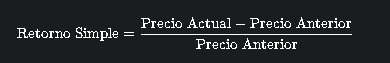

In [21]:
# Make sure that the index is DatatimeIndex and is ordered
df_bitcoin = df_bitcoin.sort_index()

# Calculate Simple returns from the Closing Price
df_bitcoin['Simple_Returns'] = df_bitcoin['Close'].pct_change() # 'pct_change()': Pandas method that calculates the percentual change from the actual price and the before price. The first value is 'Non' since there's no before price to calculate the return.


- Log Returns:
    * Natural logarithm relation from the actual price and the before price.

   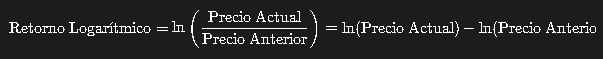
       


In [22]:
# Calculate the Log Returns from Closing Price
# Use .shift(1) to obtain prince from day before. First value will be 'NaN'. 
df_bitcoin['Log_Returns'] = np.log(df_bitcoin['Close'] / df_bitcoin['Close'].shift(1))


### 2.2 Moving Averages (MA)
They're technical indicators that smoothes price data creating a average price constantly updated. They're help you identify the direction of a tendency and it's change.

####     2.2.1 Simple Moving Average (SMA)
It's the average price of an asset during a certain number of periods (e.g., 50 days, 200 days). Every new price data gets in while the oldest data is deleted. P_i = Price in period i | n = Number of periods. Can help you determine for a bullish/bearish tendency. 

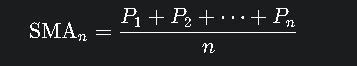
    

In [23]:
# Use .rolling(window=n).mean() which is a Pandas method to calculate SMA

# SMA 20 days (short window)
df_bitcoin['SMA_20'] = df_bitcoin['Close'].rolling(window=20).mean()

# SMA 50 days (medium window)
df_bitcoin['SMA_50'] = df_bitcoin['Close'].rolling(window=50).mean()

# SMA 200 days (Long window)
df_bitcoin['SMA_200'] = df_bitcoin['Close'].rolling(window=200).mean()



####     2.2.2 Exponential Moving Average (EMA) 
Similar to SMA, but this one gives more priority to the most recent prices. Reacts faster to changes than SMA. It calculates with a recursive formula where every new EMA depends on the previous EMA and the actual price. e.g., grades ponderation where the most recent grade has more weight in your final average. 

In [24]:
# Use ewm(span=n, adjust=False).mean() Pandas method to calculate EMA

# EMA 12 days (short window, commun for Moving Average Convergence Divergence (MACD))
df_bitcoin['EMA_12'] = df_bitcoin['Close'].ewm(span=12, adjust=False).mean()

# EMA 26 days (Medium window, common for MACD)
df_bitcoin['EMA_26'] = df_bitcoin['Close'].ewm(span=26, adjust=False).mean()



### 2.3 Volatility 
Measures the variation of the price of an asset during a specified period. It's a key risk measurement.

#### 2.3.1 Standard Deviation of Returns (SDR)
It's used to calculate historical volatility. A high deviation means returns are dispersed considering the average which means high volatility, higher risk. 

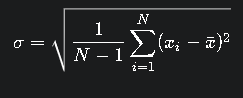

In [25]:
# Daily volatility (StandardMovil Deviation of Log Returns. e.g., 30 days)
if 'Log_Returns' not in df_bitcoin.columns:
    df_bitcoin['Log_Returns'] = np.log(df_bitcoin['Close'] / df_bitcoin['Close'].shift(1))
    
df_bitcoin['Volatility_30D'] = df_bitcoin['Log_Returns'].rolling(window=20).std()



##### Add volatility for different windows like (7 days, 14 days, 20 days, 60 days).

### 2.4 High-Low Range
Difference from the highest price to the lowest price during a period (in this case is 1 day). A High range means that the price moved a lot during that day. It also indicates that there are high trading activity or uncertainty periods. Unusual ranges, big or small, could precede significant price movement.

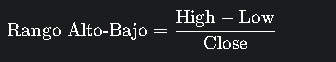

In [26]:
# Calculate the daily range percetage from Closing Price.
df_bitcoin['Daily_HighLow_Range_Pct'] = (df_bitcoin['High'] - df_bitcoin['Low']) / df_bitcoin['Close']



### 2.5  Relative Strength Index (RSI)
An RSI Above 70 (or 80) suggest that there's overbuying and maybe there's going to be a correction at the bearish. An RSI Below 30 (or 20) suggest that there's overselling, suggesting that it could bounce back to bullish.  If price makes a new maximum, but RSI doesn't could be a weekness in the trend, opposed to a bulish divergency.

In [27]:
# Calculate the Relative Strength Index (RSI) Using the RSIIndicator method from ta library
df_bitcoin['RSI'] = RSIIndicator(close=df_bitcoin['Close'], window=14).rsi()


### 2.6  Moving Average Convergence Divergence (MACD) 

- It is an indicator that follows trends and shows the relationship between two Exponential Moving Averages (EMA) of the price of an asset. It has three components:
    * MACD Line: Difference between a fast EMA (12 periods) and a Slow EMA (26 periods)
    * Signal Line: EMA of MACD Line
    * Histogram MACD: Difference between MACD Line and Signal Line
- A positive MACD suggests a bullish momentum, a negative a bearish momentum. 
    * Bullish cross: MACD line crosses above signal line (buy signal).
    * Bearish cross: MACD line crosses below signal line (Sell).
    * Line 0 cross: MACD Line crosses below or above 0.

In [28]:
# Calculate  Moving Average Convergence Divergence (MACD)  using the MACD method from ta
macd_indicator = MACD(close=df_bitcoin['Close'], window_fast=12, window_slow=26, window_sign=9)

# Define the MACD Line column
df_bitcoin['MACD_Line'] = macd_indicator.macd()
# Define the MACD Signal Line column
df_bitcoin['MACD_Signal_Line'] = macd_indicator.macd_signal()
# Define the MACD Histogram column
df_bitcoin['MACD_Histogram'] = macd_indicator.macd_diff()


### 2.7 Bollinger Bands
- A volatility indicator that contains 3 lines:
  * Simple Moving Average (SMA): usually 20 periods as the central line
  * Upper bandwidth: Central line + (N * standard deviation of the price)
  * Down bandwidth: Central line - (N * standard deviation of the price)
  * N value is usually 2
- Bands expand when volatility is high and contract when it is low. Prices that touch or surpass the upper band could be overbought, and those that touch the lower band or drop below it could be oversold.
- "Squeezes" bands contractions usually mean that there might be significant price movements coming. 

In [29]:
# Create the object with BollingerBands method from Ta
bollinger_indicator = BollingerBands(close=df_bitcoin['Close'], window=20, window_dev=2)

# Create the middle band indicator
df_bitcoin['Bollinger_Bands_Middle'] = bollinger_indicator.bollinger_mavg()
# Create the upper band indicator
df_bitcoin['Bollinger_Bands_Upper'] = bollinger_indicator.bollinger_hband()
# Create the lower band indicator
df_bitcoin['Bollinger_Bands_Lower'] = bollinger_indicator.bollinger_lband()
# Create the Width band indicator
df_bitcoin['Bollinger_Bands_Width'] = bollinger_indicator.bollinger_wband() # Band Width


### 2.8 Lagged Features
Previous columns values (days, hours), used as new characteristics. Like the closing price from yesterday, the volumen from 3 days ago etc. They're used to model time series, since the actual value depends in a big way from his past values. They're the base for a lot of forecasting models. 

In [30]:
# Create the Lagged Closing Price from the day before
df_bitcoin['Close_Lag_1'] = df_bitcoin['Close'].shift(1) 
# Create the lagged Volume from the day before
df_bitcoin['Volume_Lag_1'] = df_bitcoin['Volume'].shift(1) 
# Create the Lagged Highest price from the day before
df_bitcoin['High_Lag_1'] = df_bitcoin['High'].shift(1) 
# Create the Lagged Lowest price from the day before
df_bitcoin['Low_Lag_1'] = df_bitcoin['Low'].shift(1) 
# Create the lagges price for the Closing Price from 7 days ago
df_bitcoin['Close_Lag_7'] = df_bitcoin['Close'].shift(1)


In [31]:
df_bitcoin.head()

,Open,High,Low,Close,Volume,Simple_Returns,Log_Returns,SMA_20,SMA_50,SMA_200,...,MACD_Histogram,Bollinger_Bands_Middle,Bollinger_Bands_Upper,Bollinger_Bands_Lower,Bollinger_Bands_Width,Close_Lag_1,Volume_Lag_1,High_Lag_1,Low_Lag_1,Close_Lag_7
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,-0.071926,-0.074643,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,457.334015,21056800.0,468.174011,452.421997,457.334015
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,-0.069843,-0.072402,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,424.440002,34483200.0,456.859985,413.104004,424.440002
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.035735,0.035111,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,394.795990,37919700.0,427.834991,384.532013,394.795990
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,-0.024659,-0.024968,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,408.903992,36863600.0,423.295990,389.882996,408.903992


### 3. Save the new enriched Data Frame with the new columns


In [32]:
# Create a variable that holds the file name
file_name = "enriched_bitcoin_historical_price.csv"

# Create the alternative route to the data folder
route_folder = os.path.join('..', 'data', 'transformed_data', file_name)

# Save the DataFrame in the specified route folder
df_bitcoin.to_csv(route_folder, index=True)

print(f"The file '{file_name}' was saved sucessfully in: {route_folder}")

The file 'enriched_bitcoin_historical_price.csv' was saved sucessfully in: ..\data\transformed_data\enriched_bitcoin_historical_price.csv


In [33]:
df_bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3948 entries, 2014-09-17 00:00:00+00:00 to 2025-07-08 00:00:00+00:00
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Open                     3948 non-null   float64
 1   High                     3948 non-null   float64
 2   Low                      3948 non-null   float64
 3   Close                    3948 non-null   float64
 4   Volume                   3948 non-null   int64  
 5   Simple_Returns           3947 non-null   float64
 6   Log_Returns              3947 non-null   float64
 7   SMA_20                   3929 non-null   float64
 8   SMA_50                   3899 non-null   float64
 9   SMA_200                  3749 non-null   float64
 10  EMA_12                   3948 non-null   float64
 11  EMA_26                   3948 non-null   float64
 12  Volatility_30D           3928 non-null   float64
 13  Daily_HighLow_Range_Pct  3948 

In [34]:
df_bitcoin.describe()

,Open,High,Low,Close,Volume,Simple_Returns,Log_Returns,SMA_20,SMA_50,SMA_200,...,MACD_Histogram,Bollinger_Bands_Middle,Bollinger_Bands_Upper,Bollinger_Bands_Lower,Bollinger_Bands_Width,Close_Lag_1,Volume_Lag_1,High_Lag_1,Low_Lag_1,Close_Lag_7
count,3948.000000,3948.000000,3948.000000,3948.000000,3.948000e+03,3947.000000,3947.000000,3929.000000,3899.000000,3749.000000,...,3915.000000,3929.000000,3929.000000,3929.000000,3929.000000,3947.000000,3.947000e+03,3947.000000,3947.000000,3947.000000
mean,23245.343060,23742.671292,22725.039220,23271.680717,1.979737e+10,0.002030,0.001387,23122.508210,22891.312934,21885.654334,...,0.793758,23122.508210,25447.484715,20797.531704,22.319866,23249.983883,1.979146e+10,23721.027726,22703.538945,23249.983883
std,27180.207828,27706.653964,26631.724744,27210.773058,2.102608e+10,0.035725,0.035965,26870.831780,26332.065412,23888.429707,...,328.320525,26870.831780,29119.499679,24746.154026,14.574172,27180.044293,2.102546e+10,27676.765154,26600.808809,27180.044293
min,176.897003,211.731003,171.509995,178.102997,5.914570e+06,-0.371695,-0.464730,226.383199,232.261620,245.701329,...,-1694.518206,226.383199,238.667469,172.011294,2.598954,178.102997,5.914570e+06,211.731003,171.509995,178.102997
25%,2232.670044,2318.385071,2140.320068,2250.042603,9.364403e+08,-0.012493,-0.012571,2421.317493,2501.554298,3122.806546,...,-70.016282,2421.317493,2749.074233,1957.141872,11.622409,2244.475098,9.354765e+08,2315.950073,2135.070068,2244.475098
50%,9987.777832,10224.472168,9720.184570,10035.710449,1.597491e+10,0.001295,0.001294,10075.447803,10004.862539,9375.968547,...,0.598909,10075.447803,11235.518462,8939.110082,18.718526,10019.716797,1.597155e+10,10215.948242,9717.982422,10019.716797
75%,37397.245117,38408.531250,36375.064453,37442.277344,3.121404e+10,0.016506,0.016371,37044.971680,38140.370000,36288.146152,...,72.089091,37044.971680,42428.731298,33038.106513,29.173167,37409.443359,3.120932e+10,38387.371094,36368.830078,37409.443359
max,111679.359375,111970.171875,109285.070312,111673.281250,3.509679e+11,0.252472,0.225119,106796.418750,106688.841250,96515.363008,...,1882.855550,106796.418750,112187.912650,102224.888045,103.500714,111673.281250,3.509679e+11,111970.171875,109285.070312,111673.281250
